In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import random
import matplotlib.image as mpimg

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
data_path = "flowers"

In [3]:
classes = os.listdir(data_path)

print("Classes Found:", classes)
print("\nNumber of images per class:\n")

for c in classes:
    path = os.path.join(data_path, c)
    print(c, ":", len(os.listdir(path)))

Classes Found: ['dandelion', 'daisy', 'rose', 'tulip', 'sunflower']

Number of images per class:

dandelion : 1052
daisy : 764
rose : 784
tulip : 984
sunflower : 733


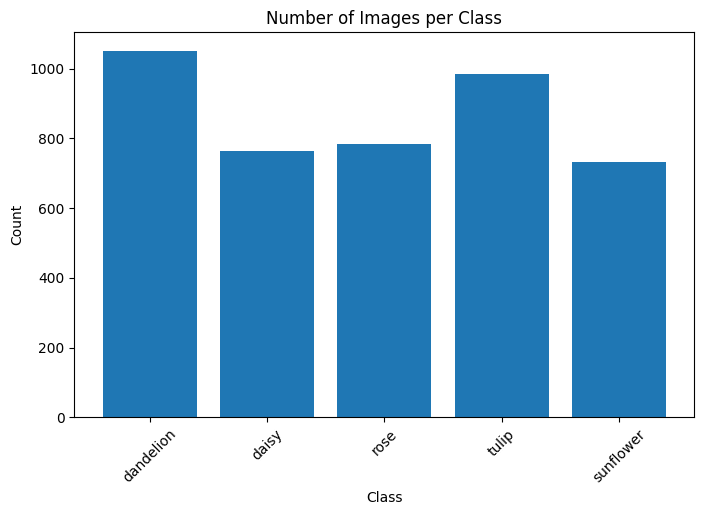

In [4]:
counts = []

for c in classes:
    path = os.path.join(data_path, c)
    counts.append(len(os.listdir(path)))

plt.figure(figsize=(8,5))
plt.bar(classes, counts)
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

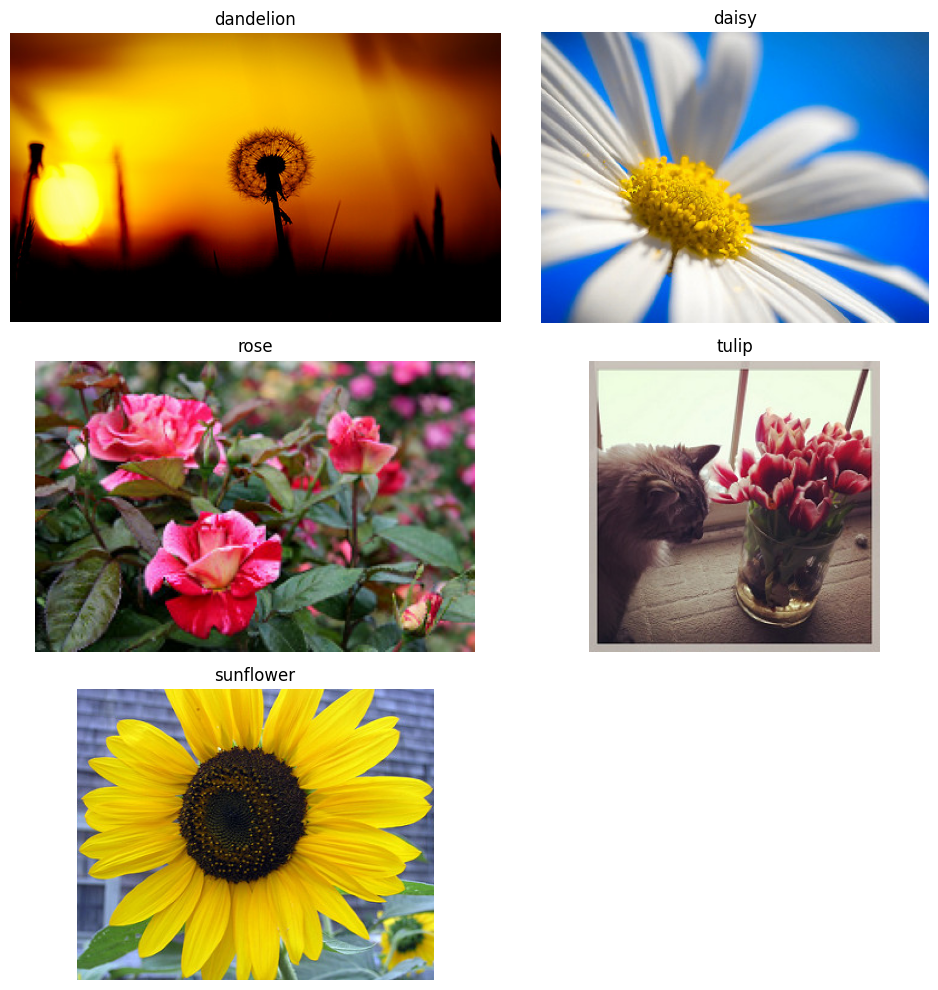

In [5]:
plt.figure(figsize=(10,10))

for i, c in enumerate(classes):
    path = os.path.join(data_path, c)
    img_name = random.choice(os.listdir(path))
    img_path = os.path.join(path, img_name)

    img = mpimg.imread(img_path)

    plt.subplot(3, 2, i+1)
    plt.imshow(img)
    plt.title(c)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

temp_data = datagen.flow_from_directory(
    data_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.


In [7]:
val_test_gen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.5
)

validation_data = val_test_gen.flow_from_directory(
    data_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

test_data = val_test_gen.flow_from_directory(
    data_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 2159 images belonging to 5 classes.
Found 2158 images belonging to 5 classes.


In [8]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [11]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=25,
    callbacks=[early_stop]
)

Epoch 1/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 24s 135ms/step - accuracy: 0.3737 - loss: 3.4146 - val_accuracy: 0.2710 - val_loss: 4.7238
Epoch 2/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.4330 - loss: 1.4155 - val_accuracy: 0.2751 - val_loss: 1.6853
Epoch 3/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.4599 - loss: 1.3483 - val_accuracy: 0.2997 - val_loss: 2.4147
Epoch 4/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.4811 - loss: 1.2283 - val_accuracy: 0.4854 - val_loss: 1.2814
Epoch 5/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.5082 - loss: 1.2226 - val_accuracy: 0.6447 - val_loss: 0.9564
Epoch 6/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.5375 - loss: 1.1524 - val_accuracy: 0.5873 - val_loss: 1.0707
Epoch 7/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.5375 - loss: 1.0836 - val_accuracy: 0.5637 - val_loss: 1.1447
Epoch 8/25
109/109 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.5745 - loss: 1.0225 - val_ac

In [12]:
test_loss, test_acc = model.evaluate(test_data)

print("\n====================")
print("TEST ACCURACY:", test_acc * 100, "%")
print("====================")

68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.8304 - loss: 0.5230

TEST ACCURACY: 83.03984999656677 %


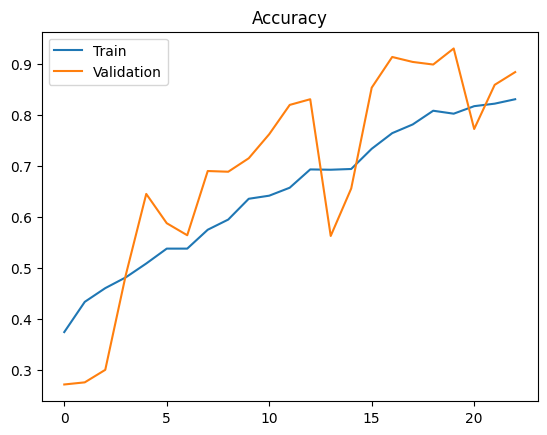

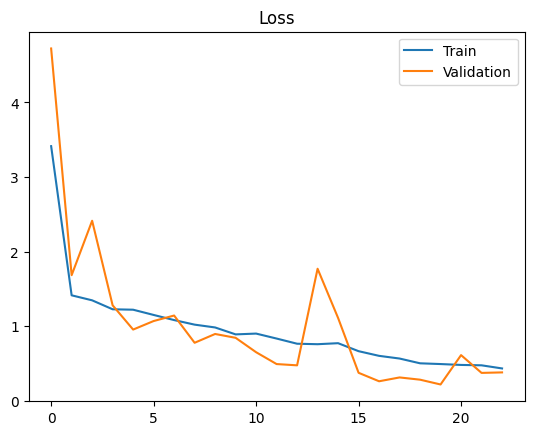

In [13]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [14]:
predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

class_names = list(test_data.class_indices.keys())

68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step


In [15]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

              precision    recall  f1-score   support

       daisy       0.79      0.86      0.83       382
   dandelion       0.85      0.91      0.88       526
        rose       0.81      0.72      0.76       392
   sunflower       0.91      0.79      0.84       366
       tulip       0.81      0.85      0.83       492

    accuracy                           0.83      2158
   macro avg       0.83      0.82      0.83      2158
weighted avg       0.83      0.83      0.83      2158



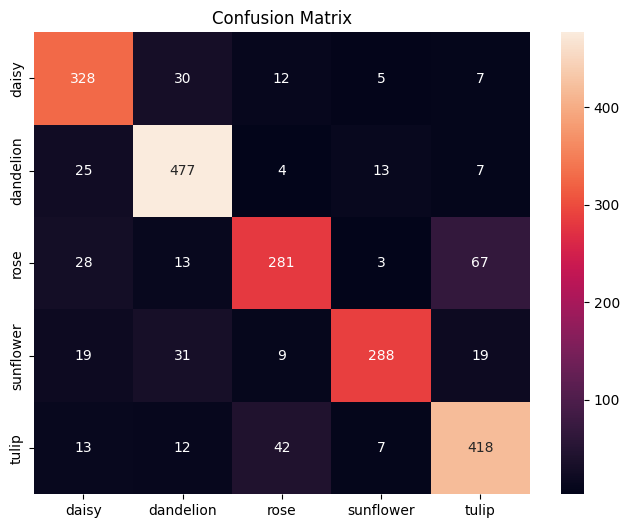

In [16]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title("Confusion Matrix")
plt.show()

In [17]:
model.save("flowers_cnn_final.h5")
print("Model Saved Successfully!")

Model Saved Successfully!


Saving لقطة شاشة 2026-05-18 215435.png to لقطة شاشة 2026-05-18 215435.png


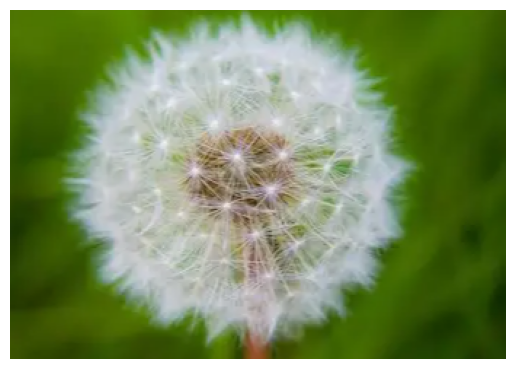

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Class: dandelion
Confidence: 100.0 %


In [20]:
# test
from google.colab import files
from tensorflow.keras.preprocessing import image
from PIL import Image


uploaded = files.upload()


img_path = list(uploaded.keys())[0]

img = Image.open(img_path).convert("RGB")


plt.imshow(img)
plt.axis("off")
plt.show()

# Prepare the image for the model
img = img.resize((128,128))

img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)

# Get the highest probability
predicted_class = np.argmax(prediction)
confidence = np.max(prediction)

# Class names
class_names = list(train_data.class_indices.keys())


print("Predicted Class:", class_names[predicted_class])
print("Confidence:", round(confidence * 100, 2), "%")